**Hello Everyone on this notebook we'll learn how to predict the handwritten numbers using the famous dataset called 'MNIST' by creating a Neural Network and predict them and visualize them graphically**

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as pt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

D:\Rohan\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
X_train = X_train / 255.0 
X_test = X_test / 255.0

In [4]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [5]:
print("Training : ", X_train.shape)
print("Testing : ", X_test.shape)

Training :  (60000, 784)
Testing :  (10000, 784)


In [6]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9281 - loss: 0.2448 - val_accuracy: 0.9656 - val_loss: 0.1131
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9692 - loss: 0.1031 - val_accuracy: 0.9704 - val_loss: 0.0941
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9780 - loss: 0.0709 - val_accuracy: 0.9763 - val_loss: 0.0750
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9832 - loss: 0.0526 - val_accuracy: 0.9792 - val_loss: 0.0716
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9861 - loss: 0.0427 - val_accuracy: 0.9755 - val_loss: 0.0850
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9894 - loss: 0.0335 - val_accuracy: 0.9770 - val_loss: 0.0754
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9762 - val_loss: 0.0904
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9919 - loss: 0.0247 -

**Above we trained the model with 3 layers of 128, 64, 10 neurons now let's visualize them  how well it has predicted it and evaluate them**

In [9]:
prediction = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step   


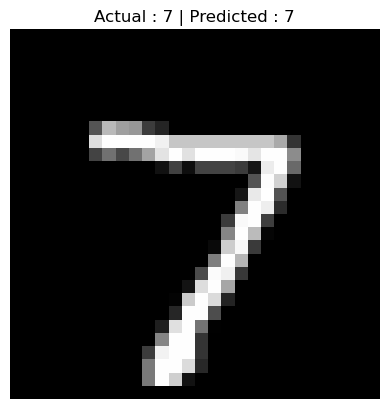

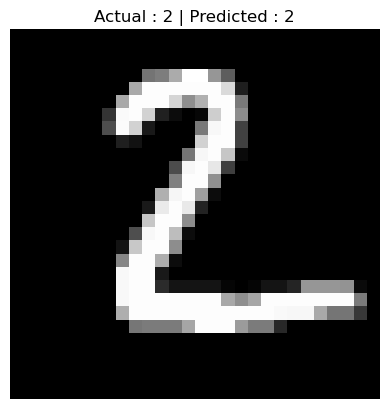

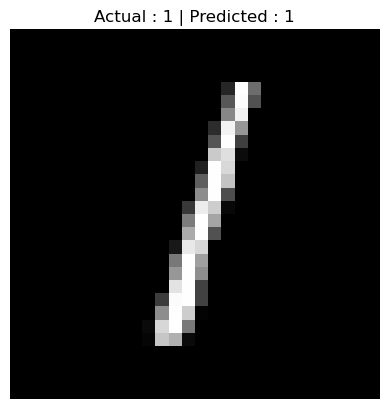

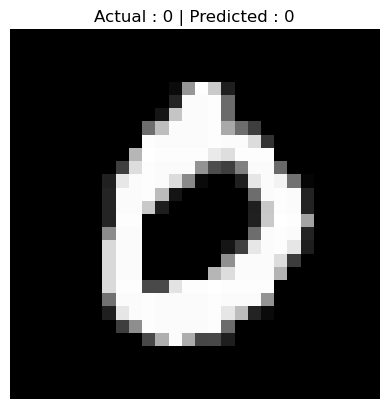

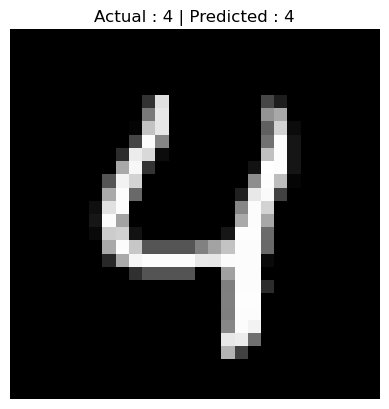

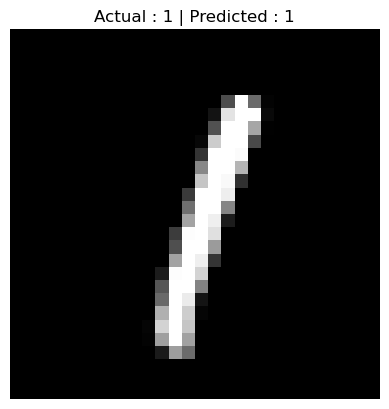

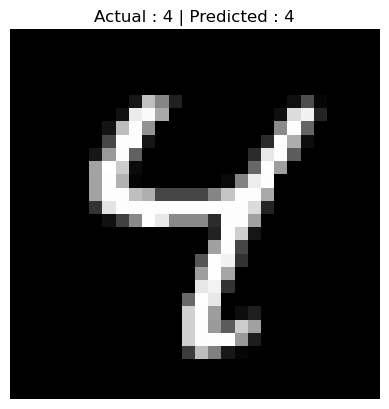

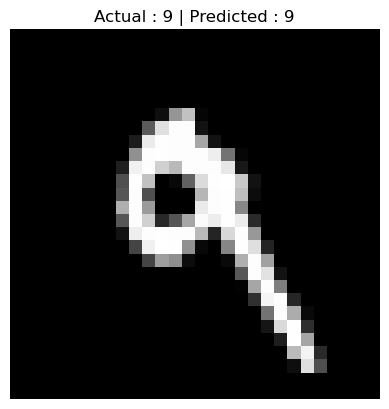

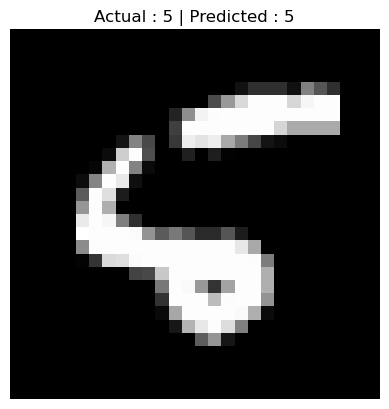

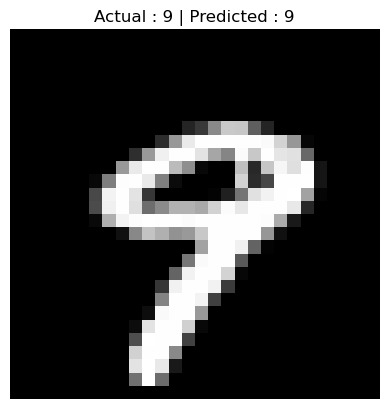

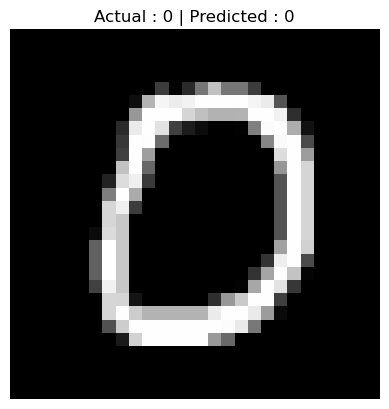

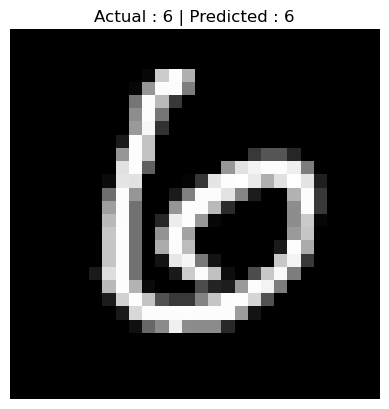

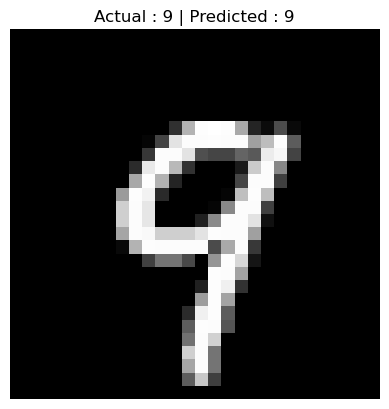

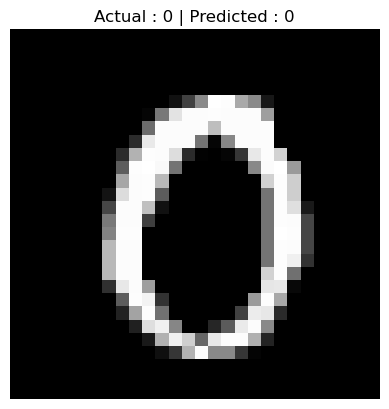

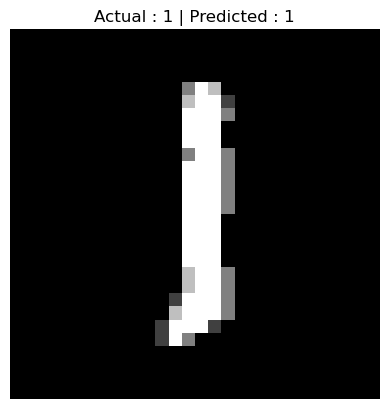

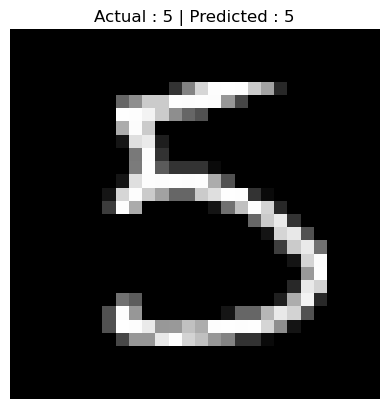

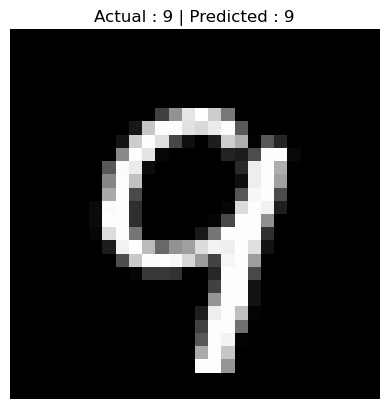

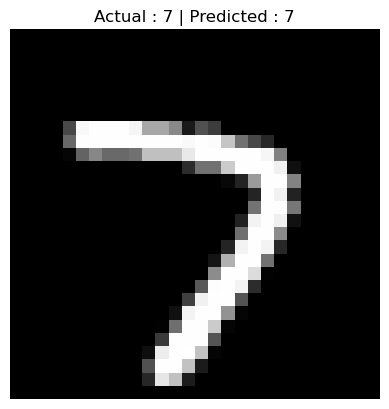

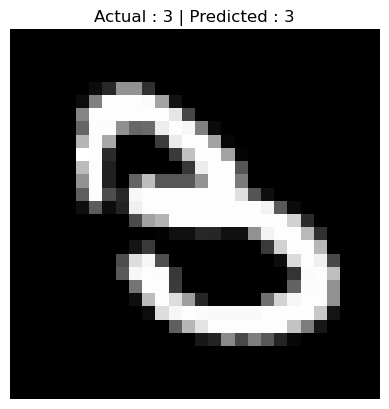

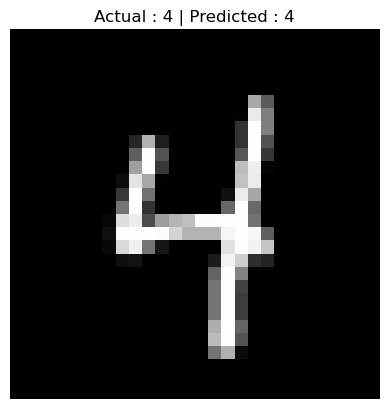

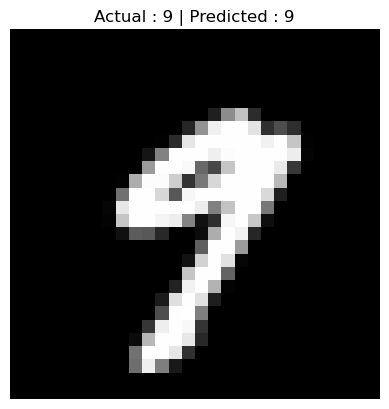

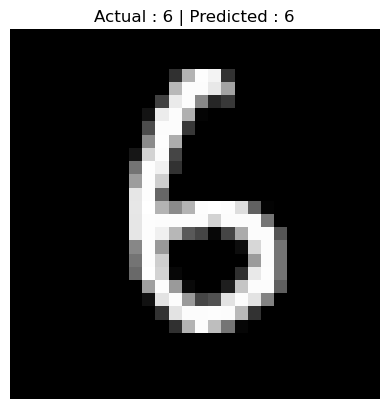

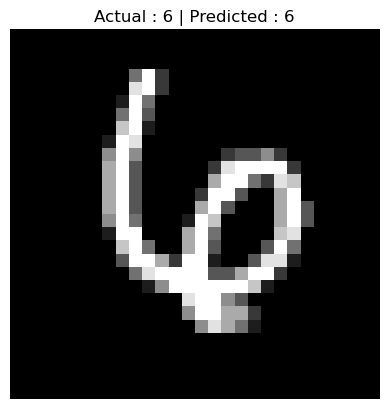

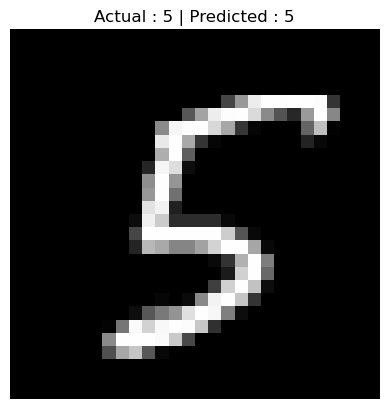

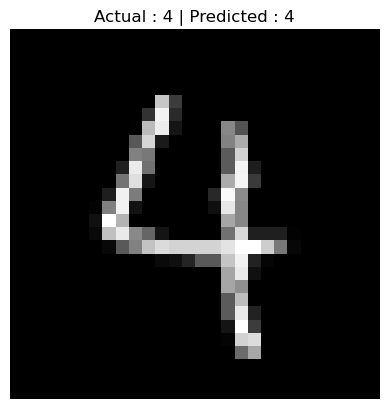

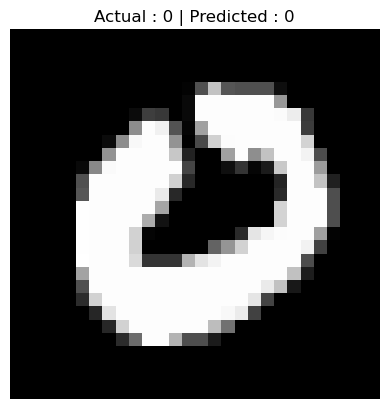

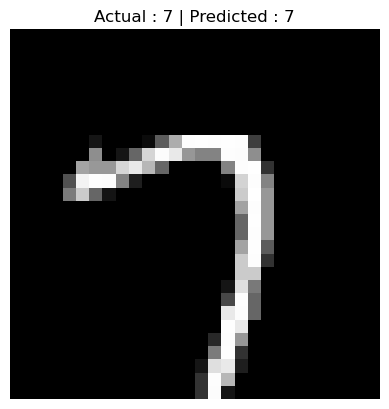

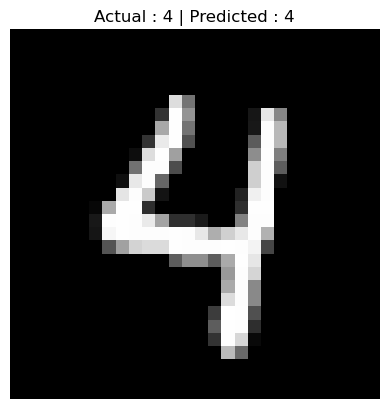

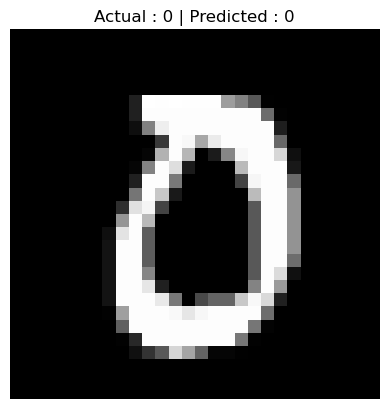

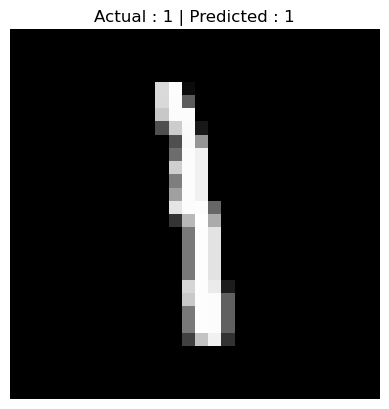

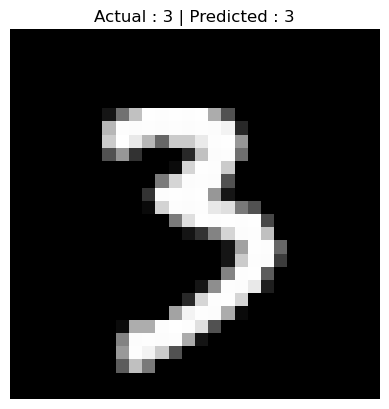

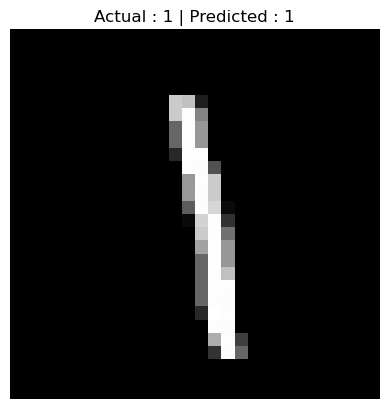

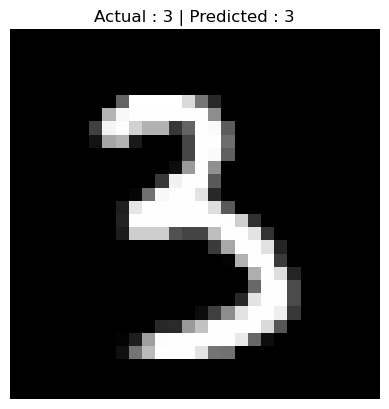

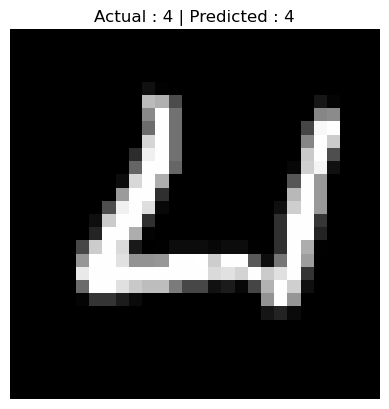

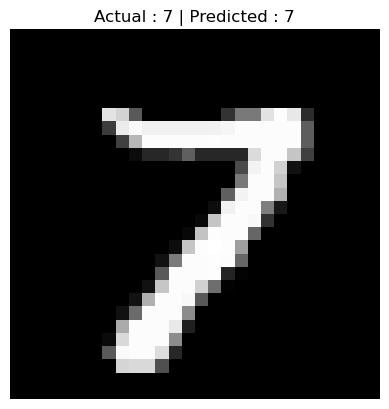

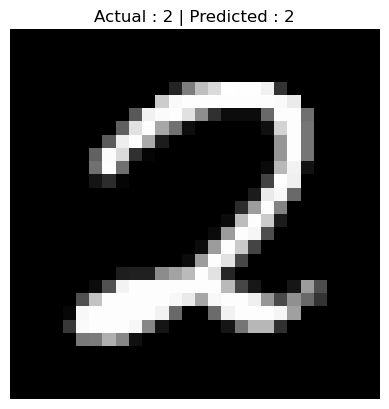

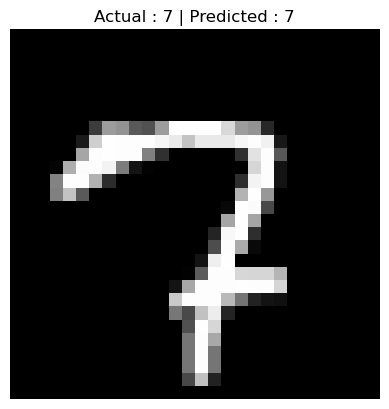

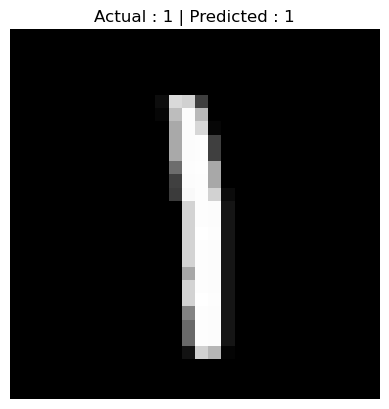

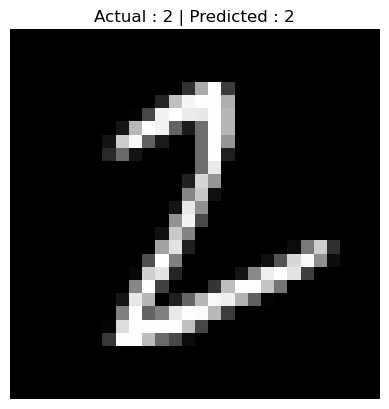

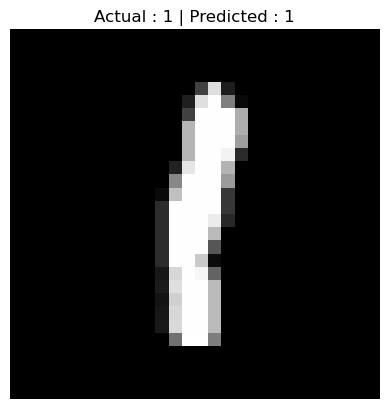

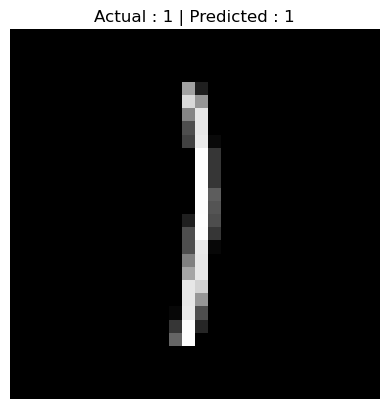

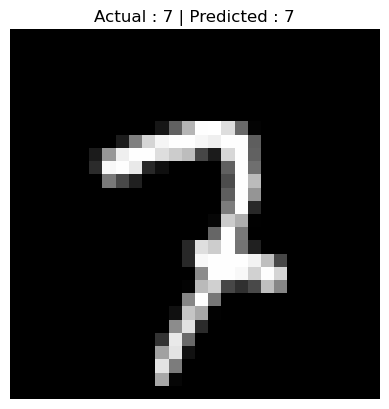

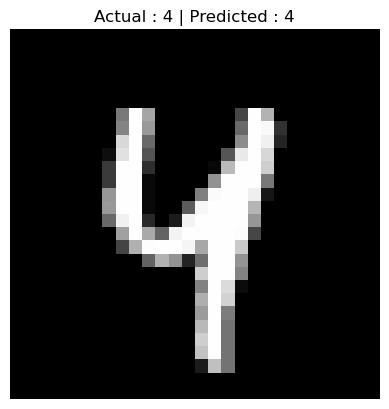

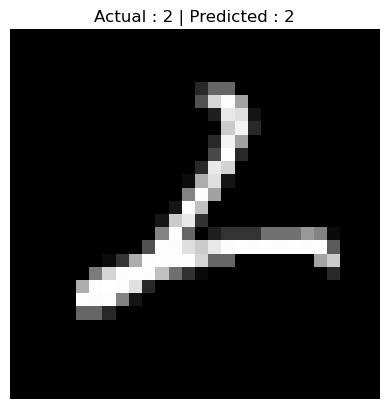

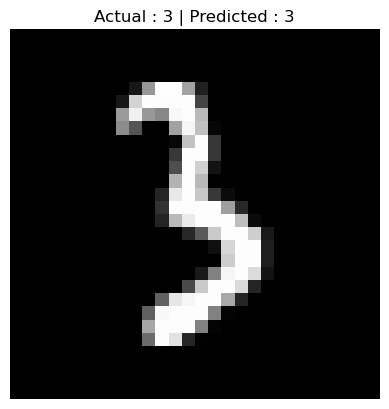

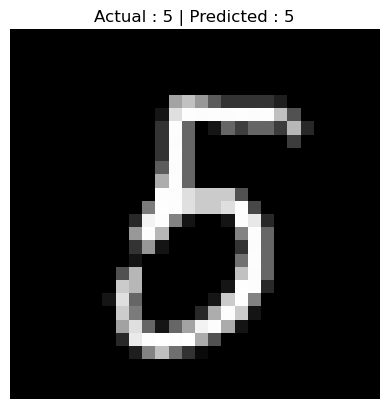

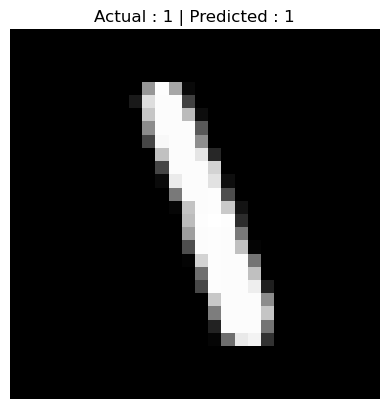

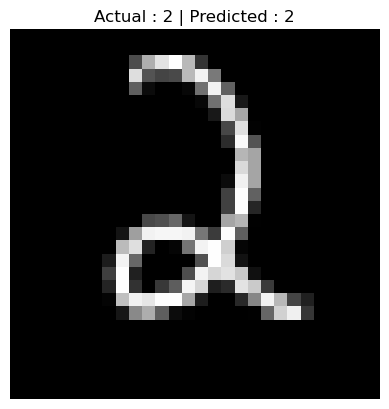

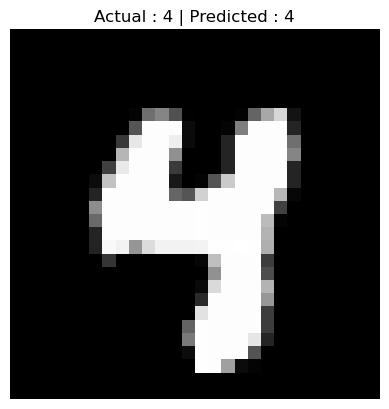

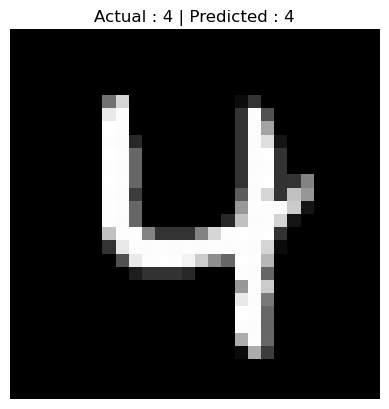

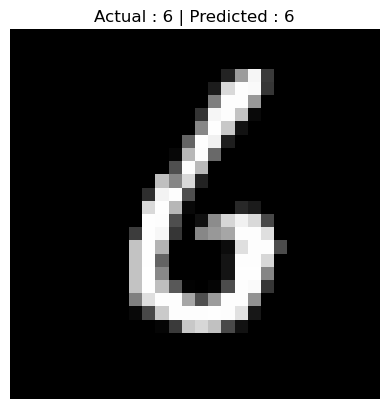

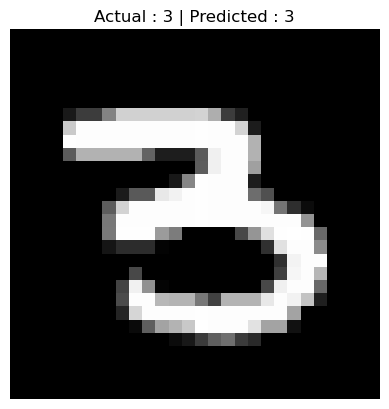

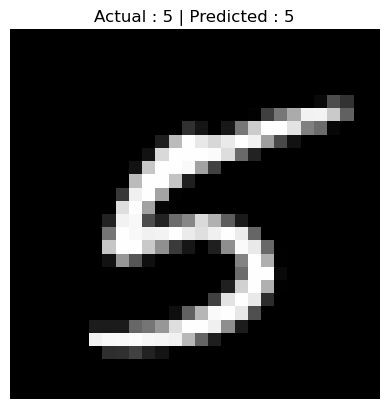

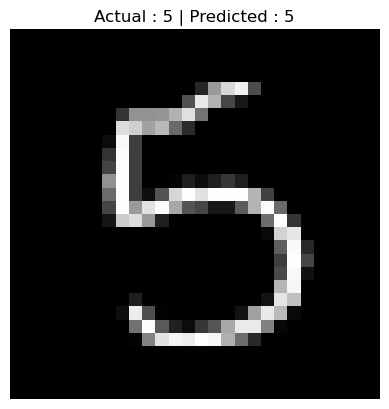

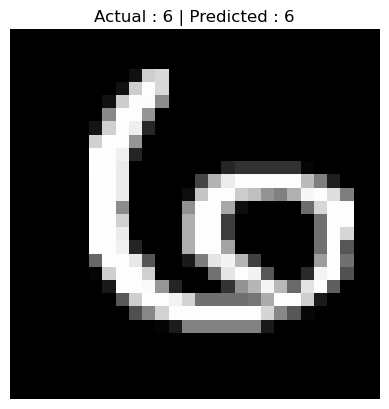

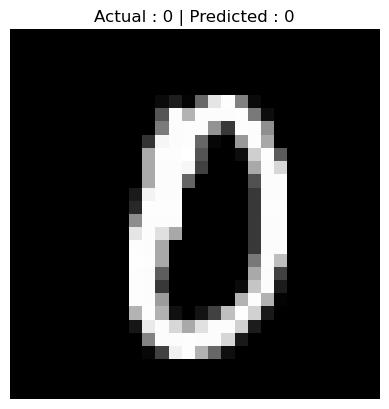

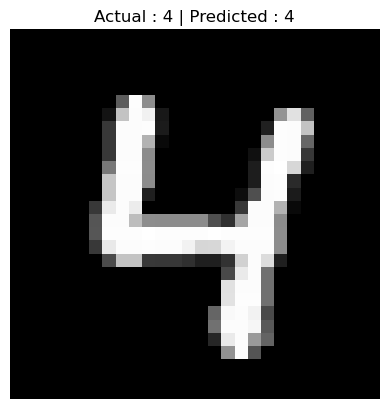

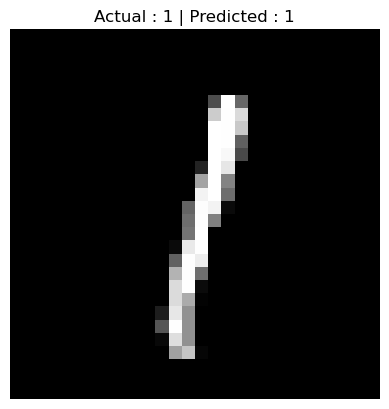

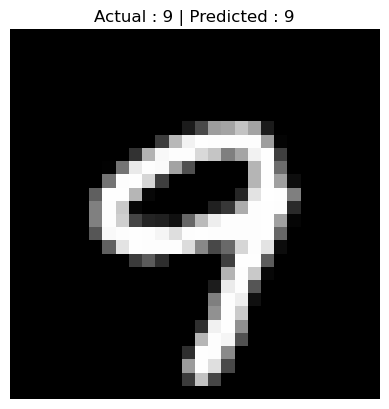

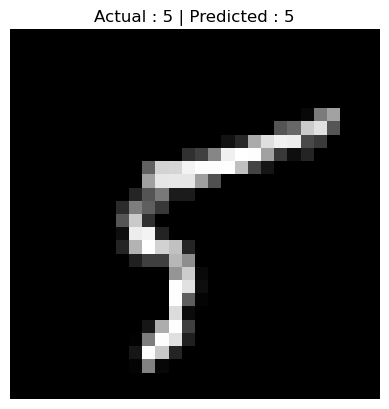

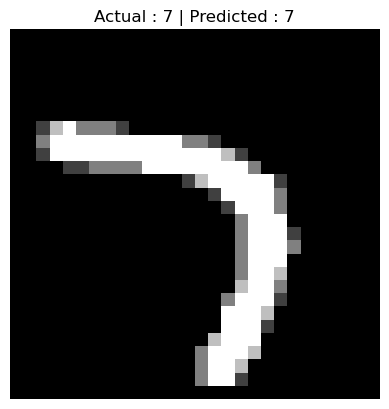

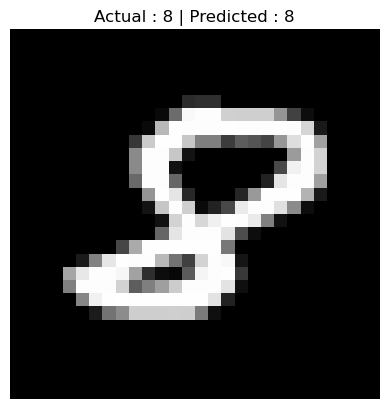

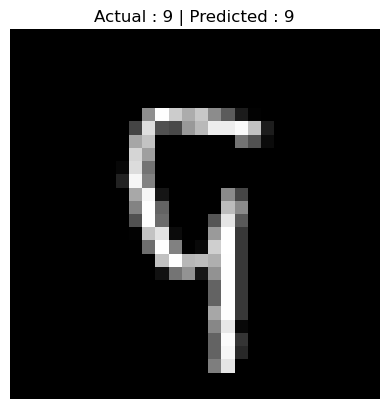

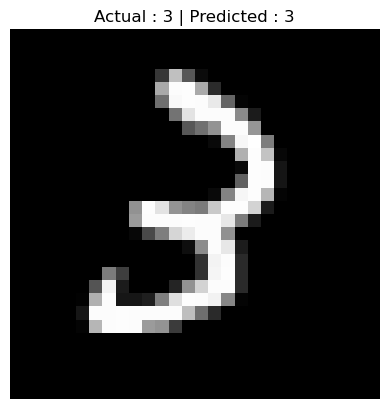

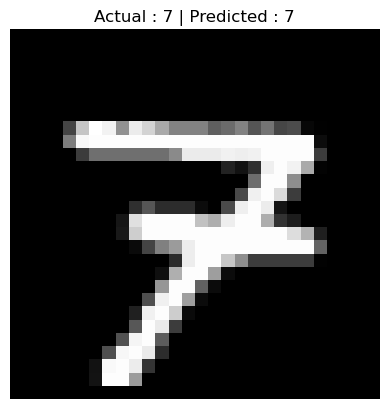

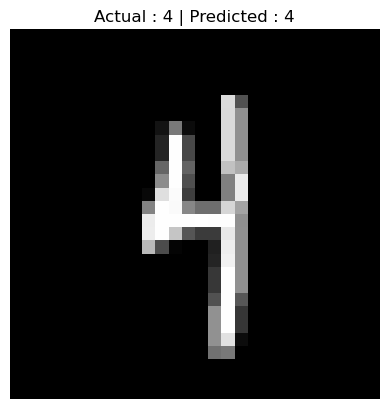

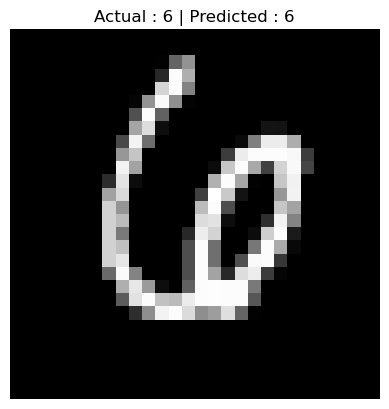

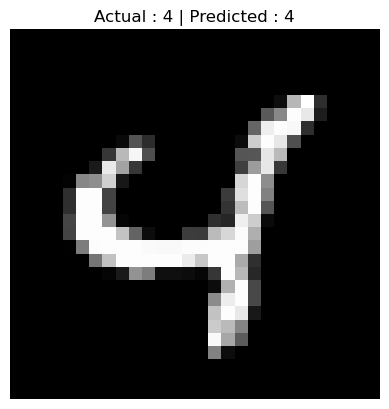

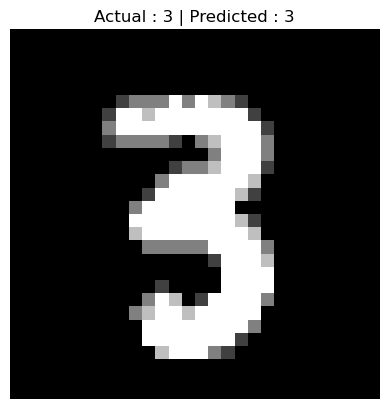

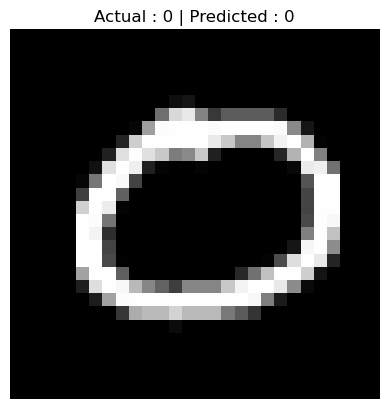

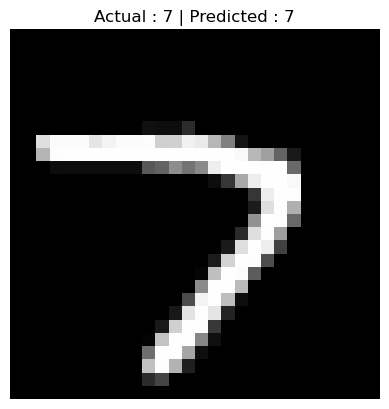

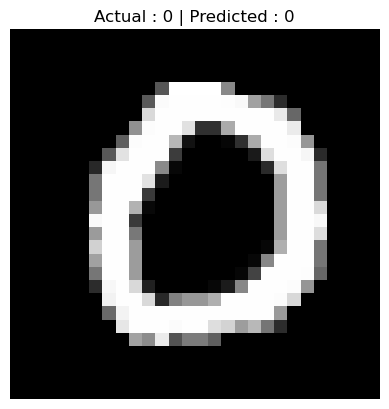

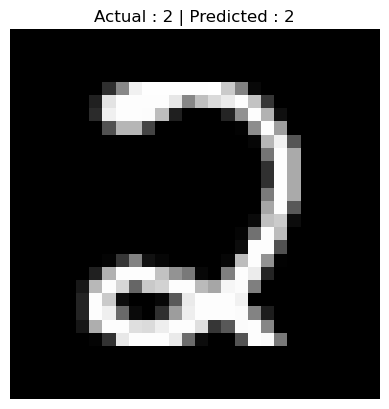

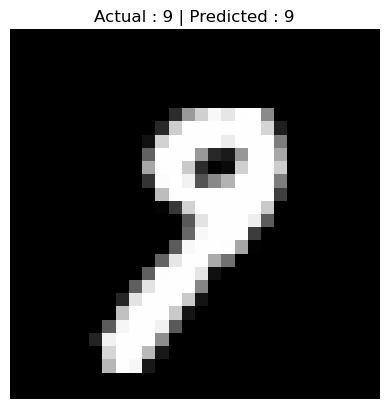

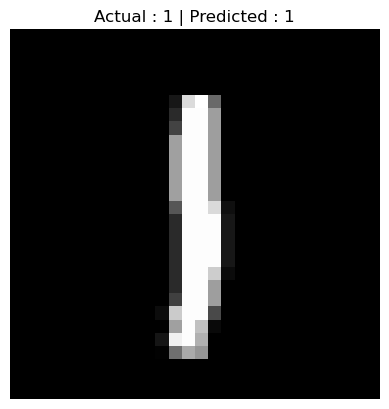

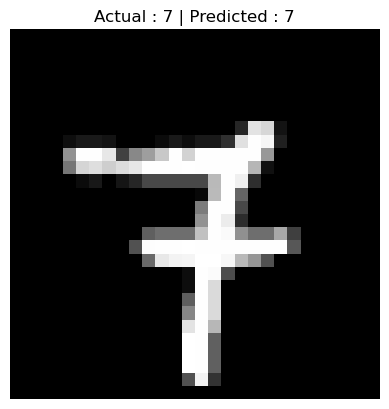

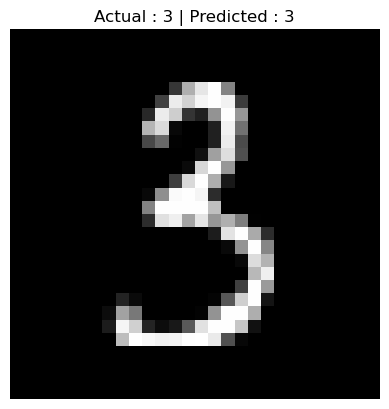

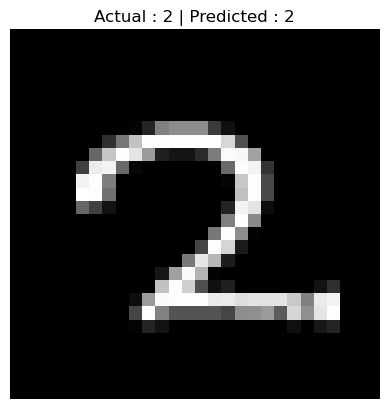

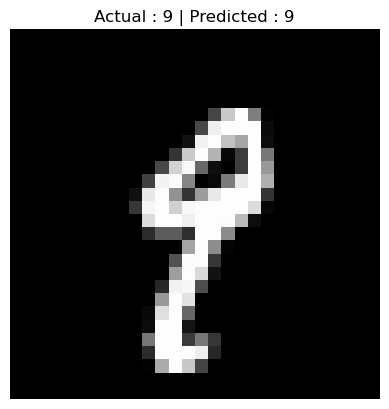

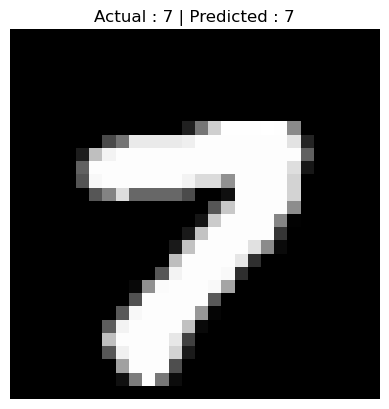

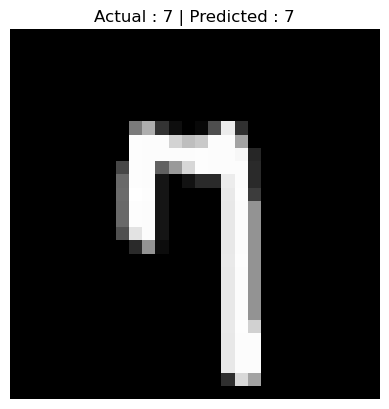

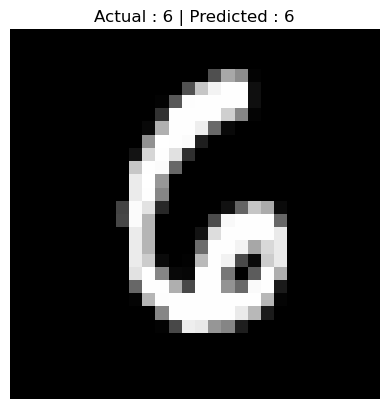

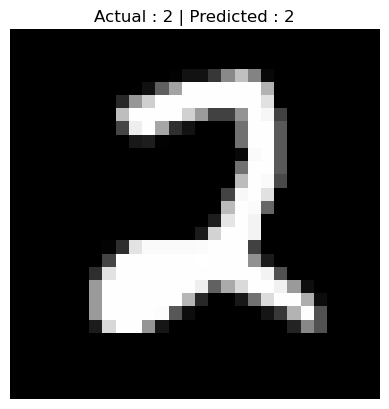

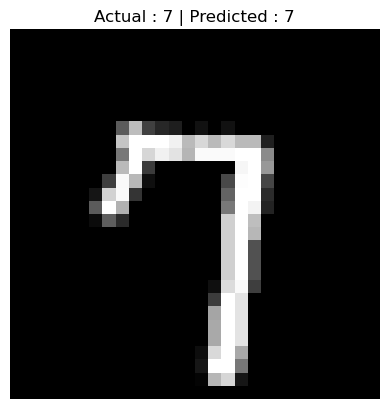

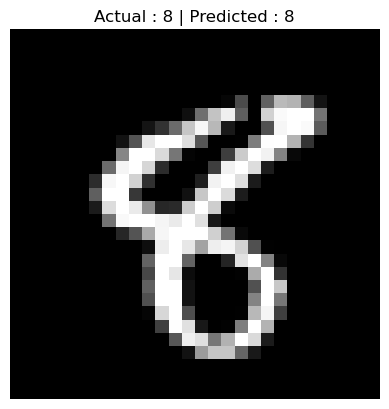

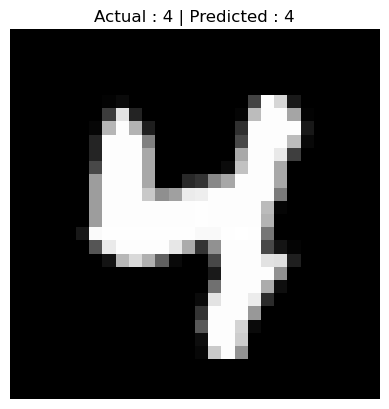

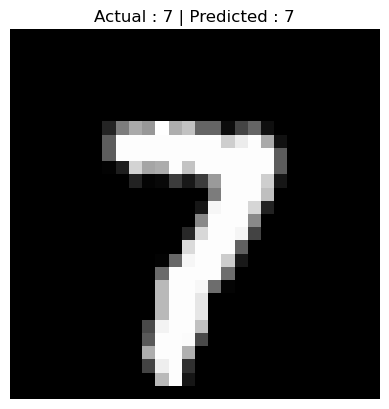

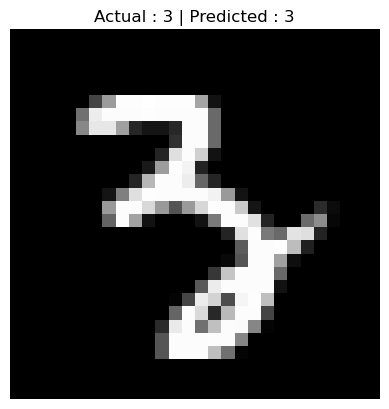

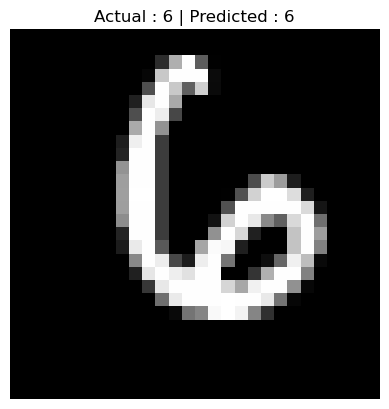

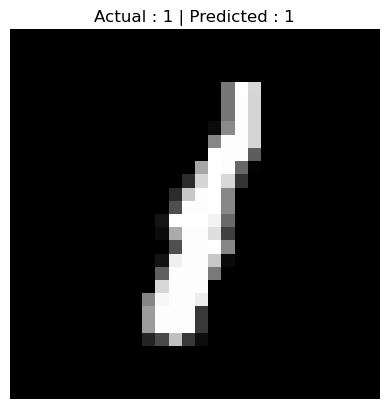

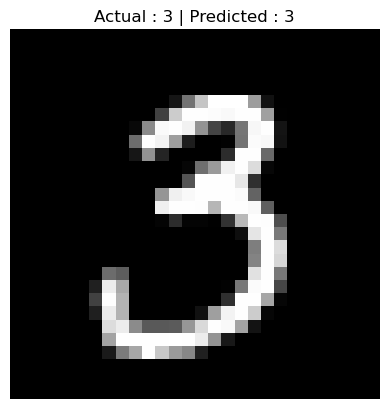

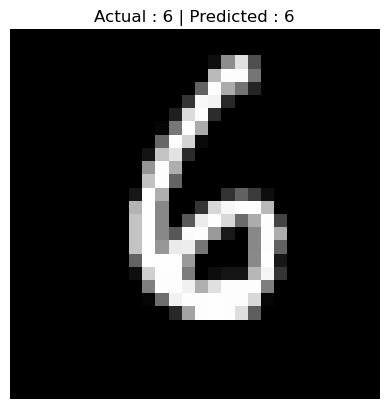

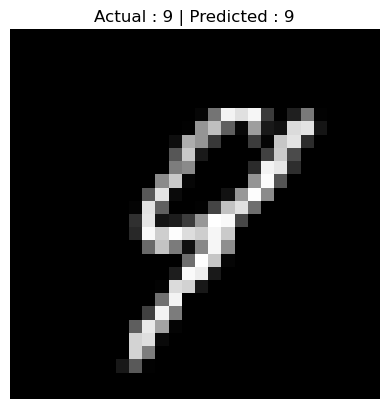

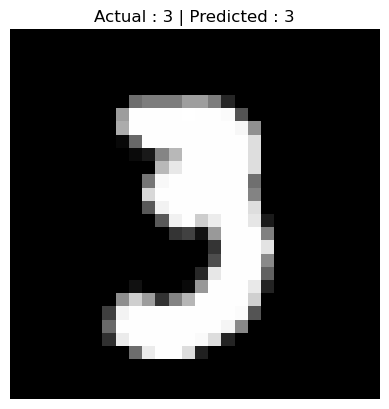

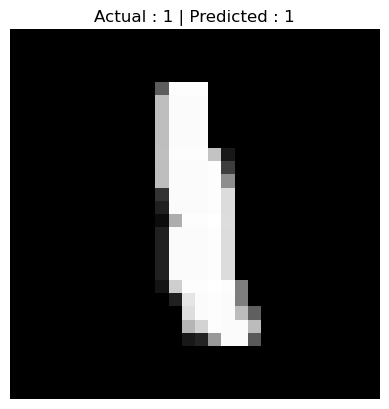

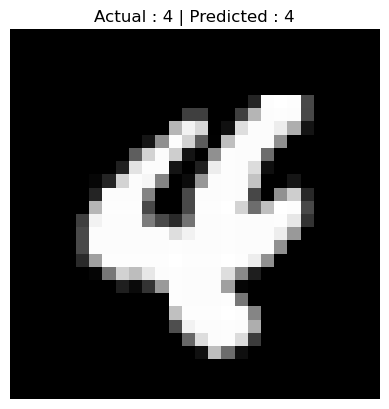

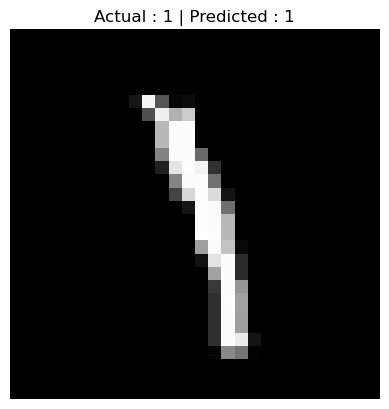

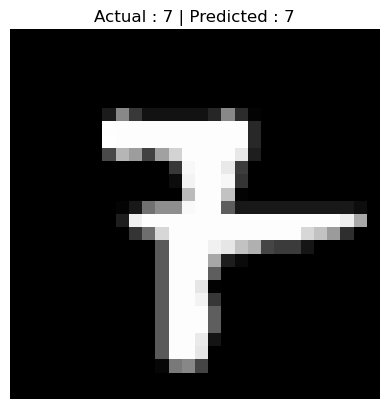

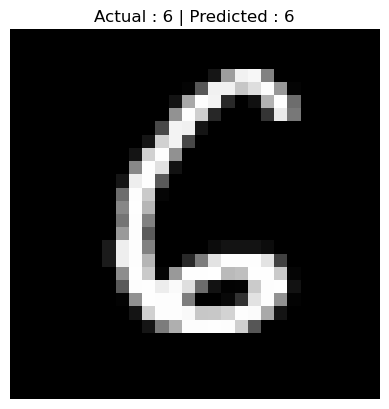

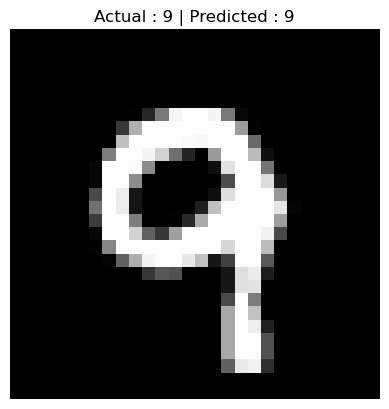

In [10]:
for i in range(100):
    pt.imshow(X_test[i].reshape(28, 28), cmap='grey')
    pt.title(f"Actual : {y_test[i]} | Predicted : {np.argmax(prediction[i])}")
    pt.axis('off')
    pt.show()

In [11]:
print(classification_report(y_test, np.argmax(prediction, axis=1)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       1.00      0.98      0.99      1135
           2       0.99      0.95      0.97      1032
           3       0.95      0.99      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.99      0.98       958
           7       0.99      0.96      0.98      1028
           8       0.96      0.97      0.96       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [12]:
print("Accuracy Score : ", accuracy_score(y_test, np.argmax(prediction, axis=1)))

Accuracy Score :  0.9763


In [13]:
print(confusion_matrix(y_test, np.argmax(prediction, axis=1)))

[[ 974    1    0    0    0    1    2    0    1    1]
 [   2 1116    2    3    0    0    4    1    6    1]
 [   6    0  983   15    1    0    3    3   20    1]
 [   0    0    2  997    1    1    0    2    0    7]
 [   1    0    2    0  961    0    5    2    0   11]
 [   2    0    0   16    1  861    4    0    6    2]
 [   3    2    0    1    1    4  945    0    2    0]
 [   0    0    5    4    6    0    0  991    5   17]
 [   6    1    1    8    3    5    0    1  944    5]
 [   1    1    0    4    5    4    2    0    1  991]]


**So we took randomly 10 numbers and predicted those numbers and it has predicted them preciously with ~98% accuracy it means it has trained perfectly**

In [14]:
from tensorflow.keras.models import load_model

In [16]:
model.save('NumPredModel.keras')